<div style="text-align: center;">

# Physics-Based (PB) Synthetic Image Generation

</div>

**Author**: Dr. Amir Omidvarnia  
**Email**: a.omidvarnia@fz-juelich.de  
**Affiliation**: Forschungszentrum Jülich, Germany  
**Event**: DPG2026 AKPIK tutorial on ML-based image processing for electrochemical applications (7 March 2026)

---

## Overview

Physics-based image synthesis generates synthetic microscopy images and their ground-truth segmentation masks **without any real labeled data**. Instead of learning from examples, it uses an explicit mathematical model of how electrochemical particles appear in SEM images: each particle is described by a parametric intensity profile (e.g., a Gaussian blob), and the image is assembled by superimposing many such particles with randomized positions, sizes, and growth states.

### Advantages of physics-based synthesis

- **No annotation required**: ground-truth masks are derived analytically from the same parameters used to generate the image.
- **Interpretable control**: physical parameters (particle size distribution, density, contrast) can be varied systematically to study their effect on segmentation performance.
- **Unlimited data**: any number of synthetic image–mask pairs can be generated without additional experimental cost.

### Two generator variants

This notebook demonstrates two physics-based generators:

1. **PB (Gaussian particles)**: particles are modeled as 2D Gaussian intensity profiles — a simple, interpretable approximation for spherical or globular electrochemical particles.
2. **PB_MoAz (non-Gaussian particles)**: particles have more complex, non-Gaussian shapes (e.g., elongated or irregular morphologies), better mimicking the diversity observed in real electrode materials.

### Workflow

1. Load the YAML configuration (particle statistics, image size, device).
2. Initialize and run the PB generator for Gaussian-like particles.
3. Visualize generated images and masks for quality assessment.
4. Repeat with the PB_MoAz generator for non-Gaussian particles and compare.

### Notebook and Repository Binding

This notebook configures physics-based image synthesis models that approximate electrochemical microstructures using analytical particle descriptions, tightly coupling simulations to the local repository so that all generated data can be traced back to explicit physical and numerical assumptions.


### Environment and Repository Setup
This cell identifies the local repository and exposes its modules within the Python path, ensuring that all subsequent physics-based simulations use a well-defined and version-controlled implementation of the synthesis models.
From a reproducibility standpoint, this step anchors the numerical experiments to a specific code base, which is essential when comparing physics-based and learning-based generation strategies across different systems or computing environments.

In [1]:
# Add repo root to sys.path so `import src` resolves to the local 'modules/' package
from pathlib import Path
import sys

try:
    notebook_dir = Path(__file__).resolve().parent
except Exception:
    notebook_dir = Path.cwd()

cur = notebook_dir
repo_root = None
for _ in range(6):
    if (cur / 'src').exists():
        repo_root = cur
        break
    if cur.parent == cur:
        break
    cur = cur.parent

if repo_root is None:
    repo_root = Path.cwd()

modules_dir = repo_root / 'src'
repo_root_str = str(repo_root)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)
print(f'Added repo root to sys.path: {repo_root_str} (src dir: {modules_dir})')

Added repo root to sys.path: /Users/amir/GIT_repositories/DPG2026_release (modules dir: /Users/amir/GIT_repositories/DPG2026_release/modules)


### Scientific Tooling and Modules
Here we assemble numerical, plotting, and image I/O libraries together with the preparation and synthesis modules provided in this project, defining the computational toolbox used to implement the physics-based models.
Conceptually, this separates the representation of physical processes (particle growth and morphology) from their numerical realisation, which supports clear reasoning about how modelling choices influence the statistics of the generated electrochemical microstructures.

In [2]:
# Import necessary modules
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)


from src.synth_data_module import SynthDataGenerator
from src.synth_data_module import ConfigLoader
from src.synth_data_module import PreparationManager

/Users/amir/GIT_repositories/DPG2026_release/.dpg2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Global Configuration and Device Selection
This block loads a YAML configuration that encodes shared parameters for all physics-based generators and selects the computational device, thereby defining the experimental context (image size, particle statistics, and hardware) for the synthetic dataset.
Treating these settings as explicit experimental factors makes it possible to study how variations in physical and numerical parameters propagate into changes in the morphology and variability of the simulated electrochemical images.

In [3]:
# Load configuration from YAML file
config_path = repo_root / 'tutorial_parameters.yaml'
config = ConfigLoader(config_path)
logging.info(f"Configuration loaded from: {config_path}")

# Specify dataset and device
dataset = 'dataset_PB'
device = "cuda" if torch.cuda.is_available() else "cpu"
logging.info(f"Using device: {device}.")

2026-02-25 15:25:22 - INFO - Configuration loaded from: /Users/amir/GIT_repositories/DPG2026_release/tutorial_parameters.yaml
2026-02-25 15:25:22 - INFO - Using device: cpu.


### Basic Physics-Based Generator (PB) with Gaussian-like Particles
This section instantiates and runs the basic physics-based generator, which represents particles as parametric Gaussian-like objects whose size, position, and temporal evolution emulate simplified electrochemical growth dynamics.
By mapping a small set of interpretable physical parameters (such as growth rate and accumulation behaviour) to image sequences, this model provides a controllable benchmark for understanding how specific microstructural mechanisms influence segmentation and tracking algorithms.

In [4]:
# Initialize PreparationManager and Generator for PB
method_name = 'PB'

# Ensure required top-level config keys exist (provide sensible defaults if missing)
cfg_dict = getattr(config, 'config', None)
if cfg_dict is None:
    raise RuntimeError('ConfigLoader did not load a configuration dictionary.')
import os
if 'synth_models_dir' not in cfg_dict:
    cfg_dict['synth_models_dir'] = os.path.join(cfg_dict.get('models_dir', os.getcwd()), 'synth_models')
if 'segmentation_models_dir' not in cfg_dict:
    cfg_dict['segmentation_models_dir'] = os.path.join(cfg_dict.get('models_dir', os.getcwd()), 'segmentation_models')
# Re-wrap config back into ConfigLoader if necessary (ConfigLoader keeps reference to cfg_dict)
prep_manager_pb = PreparationManager(config, dataset, method_name)

# Use only 5 real EM frames for creating synthetic images (demonstration only)
N_images = 5
generator_pb = SynthDataGenerator(
    prep_manager=prep_manager_pb,
    config=config,
    method_name=method_name,
    N_images=N_images,
    device=device
)

print(f"\nGenerating synthetic images using {method_name}...")
generator_pb.generate()
print("Generation complete!")

2026-02-25 15:25:22 - INFO - Parameters for the model were set.
2026-02-25 15:25:22 - INFO - Preprocessing training images...



Generating synthetic images using PB...


Preprocessing images: 100%|██████████| 5/5 [00:00<00:00, 64.99it/s]
2026-02-25 15:25:22 - INFO - Training images and masks were preprocessed.
2026-02-25 15:25:22 - INFO - Test images and masks were preprocessed.
2026-02-25 15:25:22 - INFO - *******************
2026-02-25 15:25:22 - INFO - Inpainting the backgrounds of the test images.


Preprocessing complete.
Images saved to: /Users/amir/Documents/DPG2026_Tutorial/preprocessed_data/PB_dataset_PB/input_images
Masks saved to: /Users/amir/Documents/DPG2026_Tutorial/preprocessed_data/PB_dataset_PB/input_masks


Generating synthetic images for image 4: 100%|██████████| 1/1 [00:01<00:00,  1.79s/it]
2026-02-25 15:25:31 - INFO - Synthetic image and masks were generated and saved.


Generation complete!


### Qualitative Assessment of PB Outputs
Here we visualise physics-based synthetic images generated by the PB model alongside their binary masks to judge whether the simulated particles and interfaces resemble plausible electrochemical microstructures.
This qualitative inspection helps verify that the chosen physical parameters yield realistic intensity patterns and segmentation-ready masks before using the dataset for training or benchmarking downstream image analysis methods.

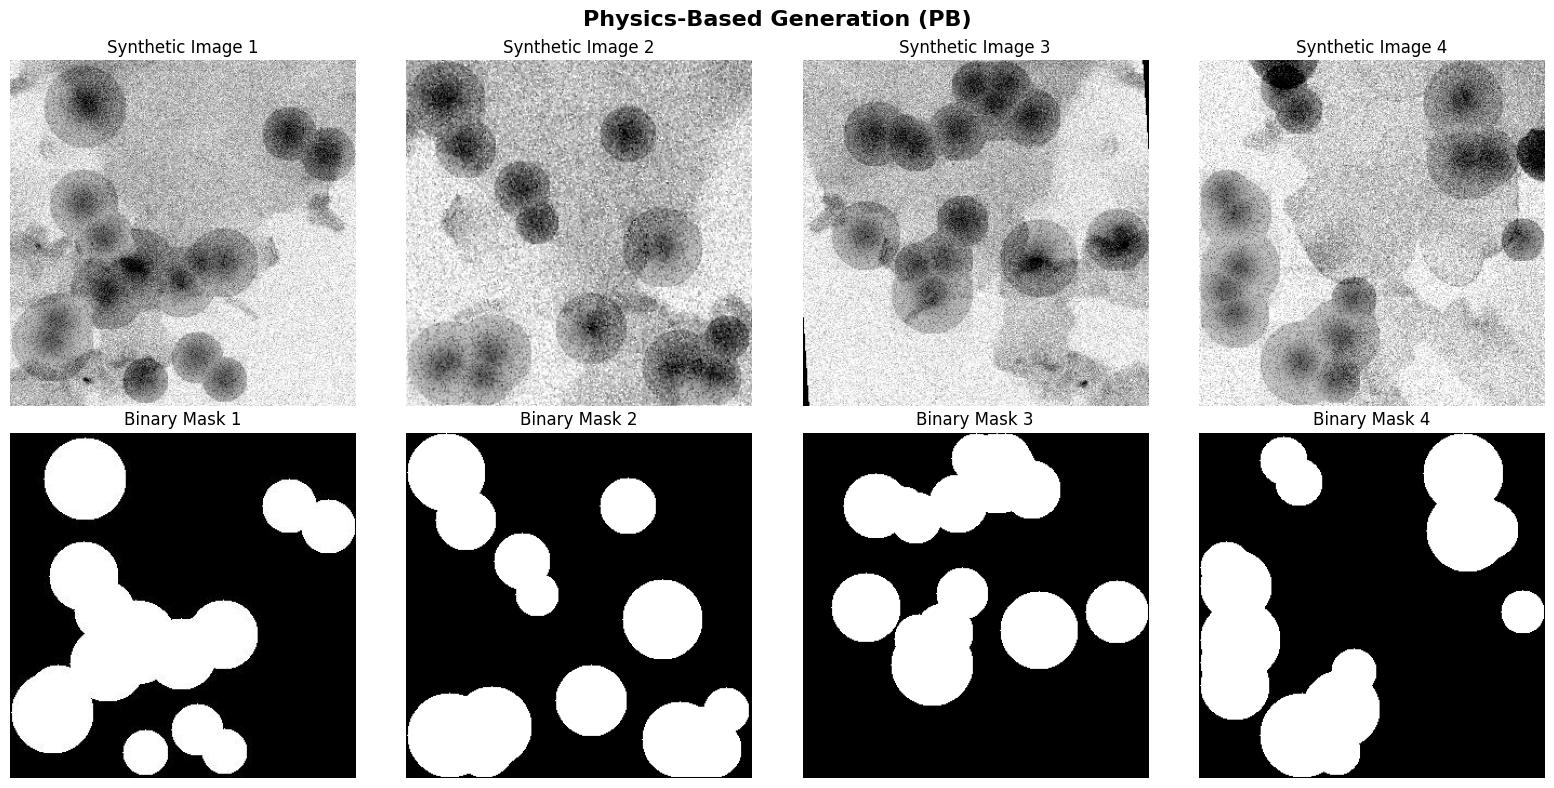

Generated 4 synthetic images using method_PB


In [5]:
# Load and display generated images from PB
output_images_dir = prep_manager_pb.output_images_dir
output_masks_dir = prep_manager_pb.output_bin_masks_dir

# Get list of generated files
image_files = sorted([f for f in os.listdir(output_images_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))])[:4]

# Create visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Physics-Based Generation (PB)', fontsize=16, fontweight='bold')

for idx, img_file in enumerate(image_files):
    # Load image and mask
    img_path = os.path.join(output_images_dir, img_file)
    mask_path = os.path.join(output_masks_dir, img_file)
    
    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))
    
    # Display image
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title(f'Synthetic Image {idx+1}')
    axes[0, idx].axis('off')
    
    # Display mask
    axes[1, idx].imshow(mask, cmap='gray')
    axes[1, idx].set_title(f'Binary Mask {idx+1}')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Generated {len(image_files)} synthetic images using method_PB")

### Physics-Based Generator with Non-Gaussian Particle Shapes (PB_MoAz)

Real electrochemical particles — such as lithium deposits, MoS₂ flakes, or porous oxide grains — often exhibit elongated, irregular, or faceted morphologies that a simple isotropic Gaussian model cannot reproduce. The `PB_MoAz` generator addresses this by using anisotropic or non-Gaussian intensity profiles that more faithfully represent such complex particle shapes.

By comparing images from the basic PB and the PB_MoAz generators side by side, one can assess how morphological complexity in the synthetic training data influences the performance of downstream segmentation models.


In [6]:
# Initialize PreparationManager and Generator for PB_MoAz
method_name = 'PB_MoAz'

# Ensure required top-level config keys exist (provide sensible defaults if missing)
cfg_dict = getattr(config, 'config', None)
if cfg_dict is None:
    raise RuntimeError('ConfigLoader did not load a configuration dictionary.')
import os
if 'synth_models_dir' not in cfg_dict:
    cfg_dict['synth_models_dir'] = os.path.join(cfg_dict.get('models_dir', os.getcwd()), 'synth_models')
if 'segmentation_models_dir' not in cfg_dict:
    cfg_dict['segmentation_models_dir'] = os.path.join(cfg_dict.get('models_dir', os.getcwd()), 'segmentation_models')
# Re-wrap config back into ConfigLoader if necessary (ConfigLoader keeps reference to cfg_dict)
prep_manager_pb_moaz = PreparationManager(config, dataset, method_name)


# Use only 1 real EM frames for creating synthetic images (demonstration only)
N_images = 1
generator_pb_moaz = SynthDataGenerator(
    prep_manager=prep_manager_pb_moaz,
    config=config,
    method_name=method_name,
    N_images=N_images,
    device=device
)

print(f"\nGenerating synthetic images using {method_name}...")
generator_pb_moaz.generate()
print("Generation complete!")

2026-02-25 15:25:32 - INFO - Parameters for the model were set.
2026-02-25 15:25:32 - INFO - Preprocessing training images...



Generating synthetic images using PB_MoAz...


Preprocessing images: 100%|██████████| 1/1 [00:00<00:00, 229.41it/s]
2026-02-25 15:25:32 - INFO - Training images and masks were preprocessed.
2026-02-25 15:25:32 - INFO - Test images and masks were preprocessed.
2026-02-25 15:25:32 - INFO - *******************
2026-02-25 15:25:32 - INFO - Inpainting the backgrounds of the test images.


Preprocessing complete.
Images saved to: /Users/amir/Documents/DPG2026_Tutorial/preprocessed_data/PB_MoAz_dataset_PB/input_images
Masks saved to: /Users/amir/Documents/DPG2026_Tutorial/preprocessed_data/PB_MoAz_dataset_PB/input_masks
**** Frame 1/5 generated and added to the sequence. ****
**** Frame 2/5 generated and added to the sequence. ****
**** Frame 3/5 generated and added to the sequence. ****
**** Frame 4/5 generated and added to the sequence. ****
**** Frame 5/5 generated and added to the sequence. ****


Generating synthetic images for frame 0:   0%|          | 0/5 [00:00<?, ?it/s]

...

**** Frame 1/1 generated and added to the sequence. ****
**** Frame 1/1 generated and added to the sequence. ****


Generating synthetic images for frame 0:  80%|████████  | 4/5 [00:07<00:01,  1.85s/it]

**** Frame 1/1 generated and added to the sequence. ****
**** Frame 1/1 generated and added to the sequence. ****


Generating synthetic images for frame 0: 100%|██████████| 5/5 [00:09<00:00,  1.83s/it]
2026-02-25 15:25:41 - INFO - =================================================
2026-02-25 15:25:41 - INFO - Synthetic image and masks were generated and saved.


**** Frame 1/1 generated and added to the sequence. ****
Generation complete!


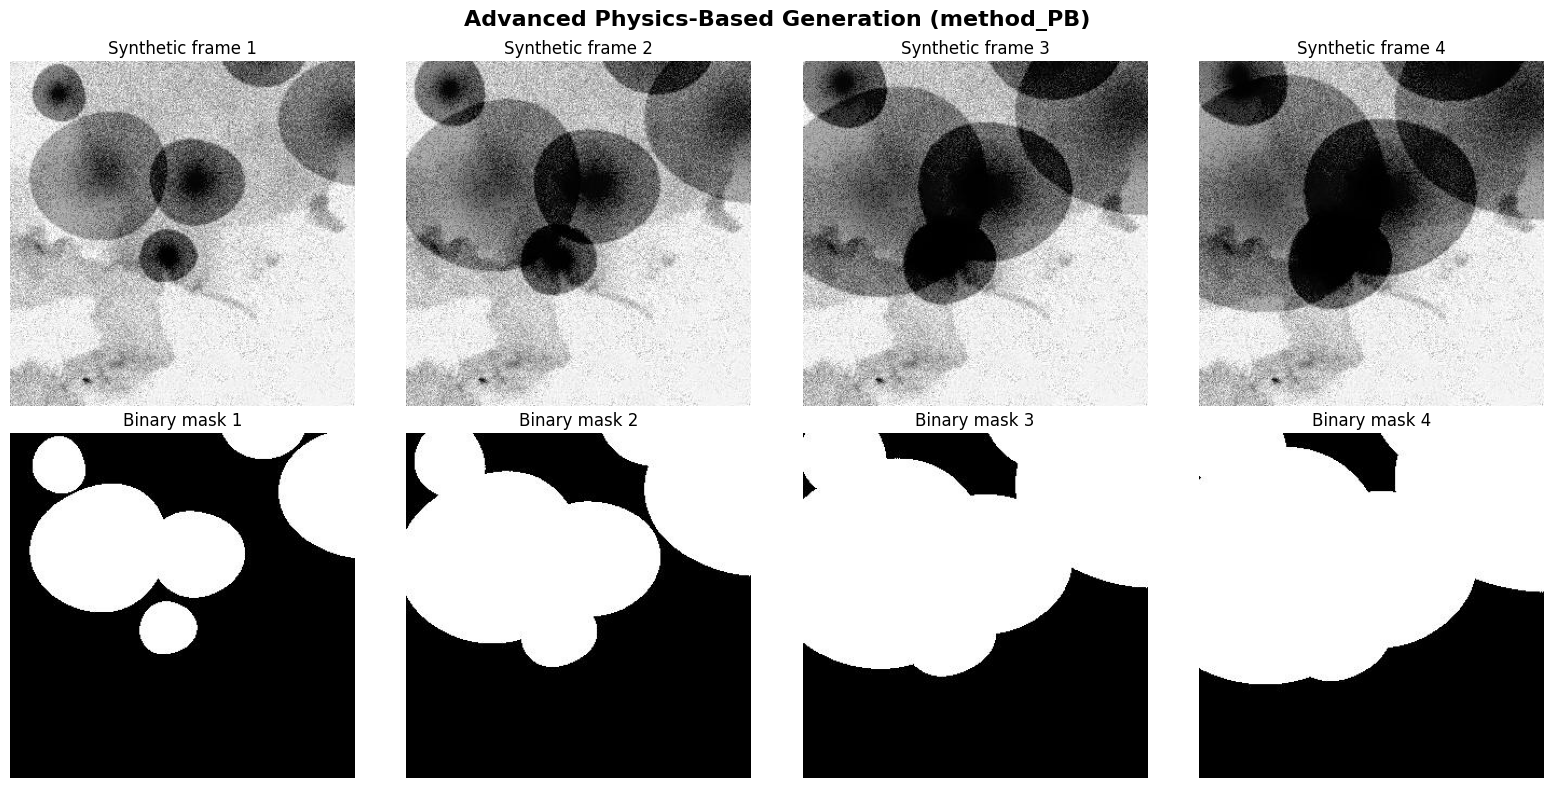

In [7]:
# Load and display generated images from method_PB
output_images_dir = prep_manager_pb_moaz.output_images_dir
output_masks_dir = prep_manager_pb_moaz.output_bin_masks_dir

# Get list of generated files
image_files = sorted([f for f in os.listdir(output_images_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))])[:4]

# Create visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Advanced Physics-Based Generation (method_PB)', fontsize=16, fontweight='bold')

for idx, img_file in enumerate(image_files):
    
    # Load image and mask
    img_path = os.path.join(output_images_dir, img_file)
    mask_path = os.path.join(output_masks_dir, img_file)

    # Convert RGBA to grayscale or use a single channel before plotting
    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))
    
    # Display image
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title(f'Synthetic frame {idx+1}')
    axes[0, idx].axis('off')
    
    # Display mask
    axes[1, idx].imshow(mask, cmap='gray')
    axes[1, idx].set_title(f'Binary mask {idx+1}')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()